# Neighbourhood enrichment analysis of celltypes, using MuSpAn

In [1]:
import anndata as ad 
adata = ad.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")

In [2]:
replicates = {}
for rep in adata.obs.batch_key.unique():
    replicates[rep] = adata[adata.obs.batch_key == rep].copy()

In [3]:
#making MuSpAn domains
import muspan as ms
import numpy as np
import matplotlib.pyplot as plt

In [44]:
del rep_domains

In [4]:
#dictionary of domains
rep_domains = {}
for name, rep in replicates.items():
    rep_domains[name] = ms.domain(f'{name}')

#add points, these will be in um if taken from xenium data
for name, domain in rep_domains.items():
    points = replicates[name].obsm['spatial']
    domain.add_points(points, 'cells')

#add labels
for name, domain in rep_domains.items():
    labels = replicates[name].obs.celltype_assignments.to_numpy()
    domain.add_labels('celltype_assignments', labels)

#estimate boundary using alphashape -- could also use compartment segmentations, similar results, given they are both defined by cell existence. 
for name, domain in rep_domains.items():
    domain.estimate_boundary(method = 'convex hull')
                             #alpha_shape_kwargs = {'alpha':15})

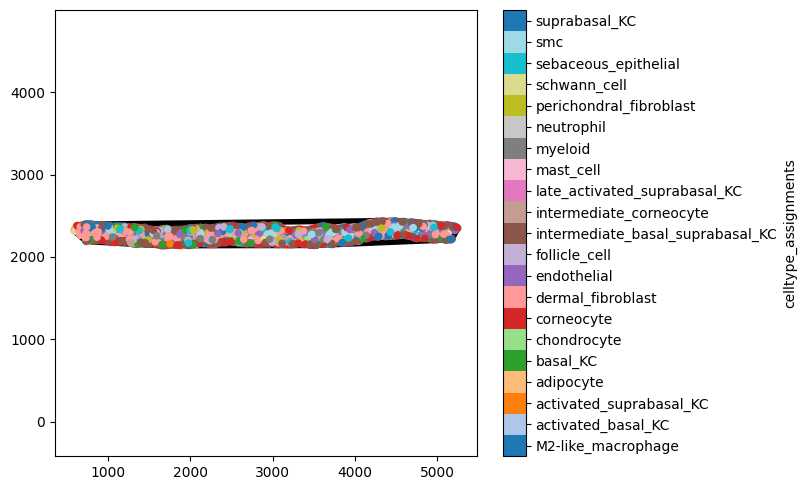

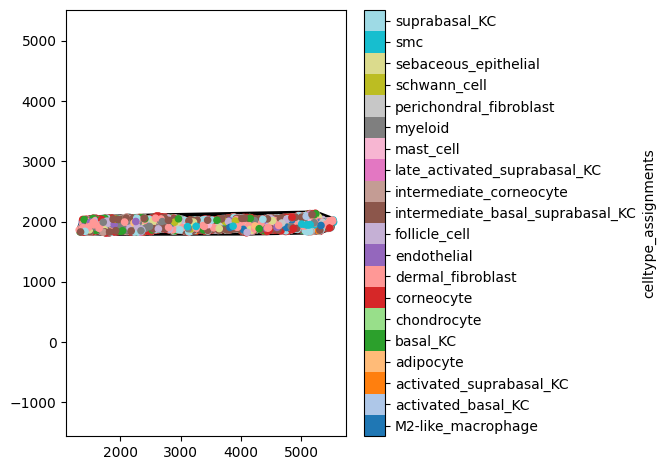

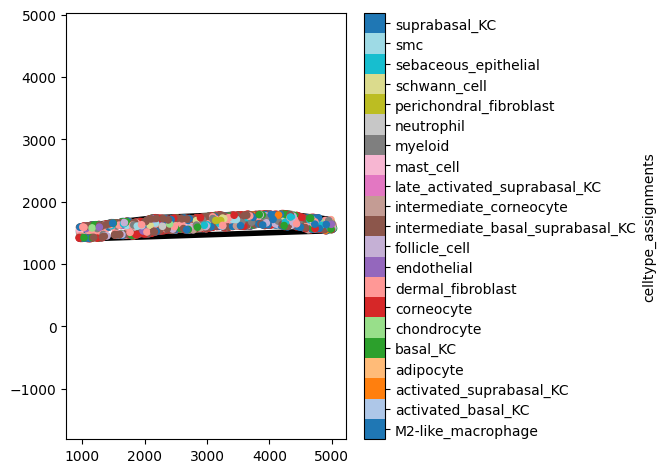

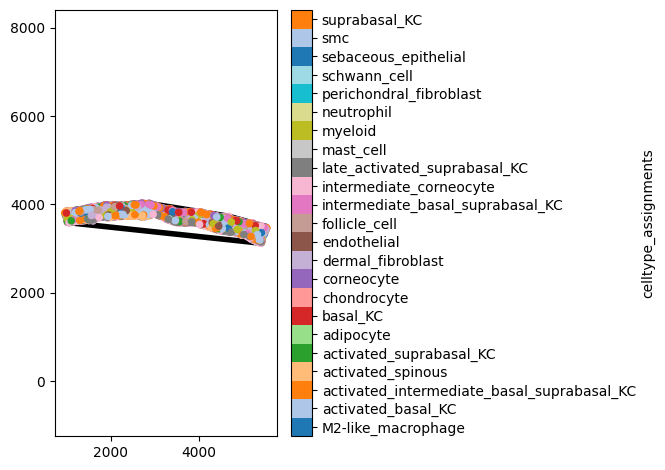

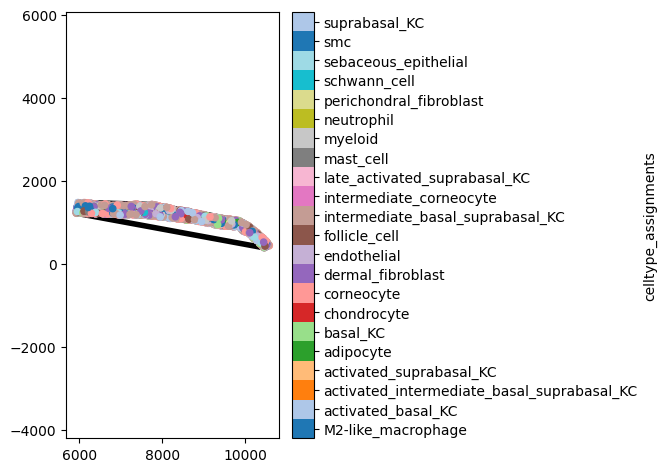

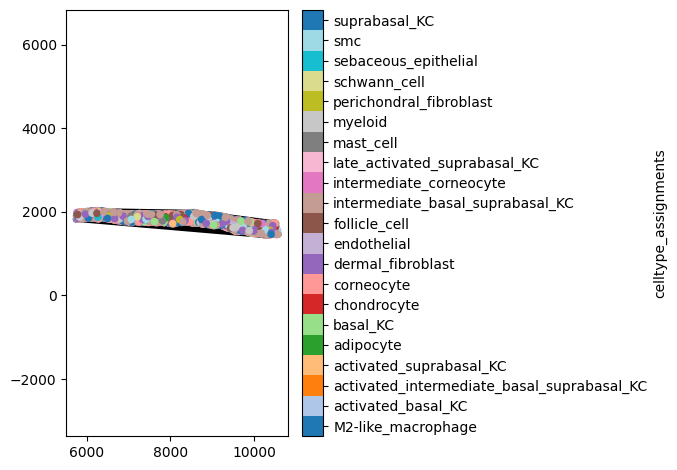

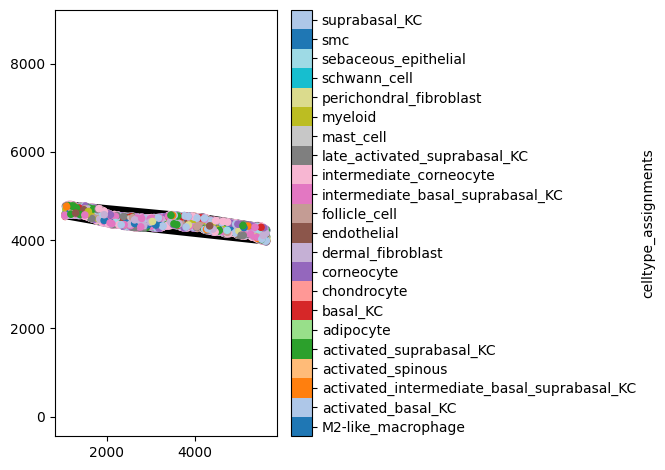

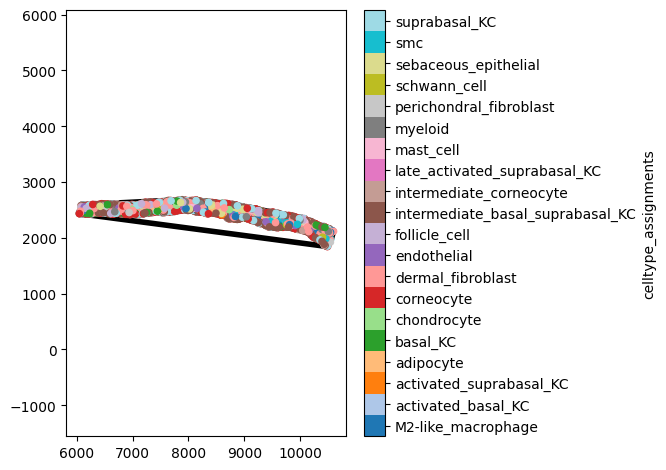

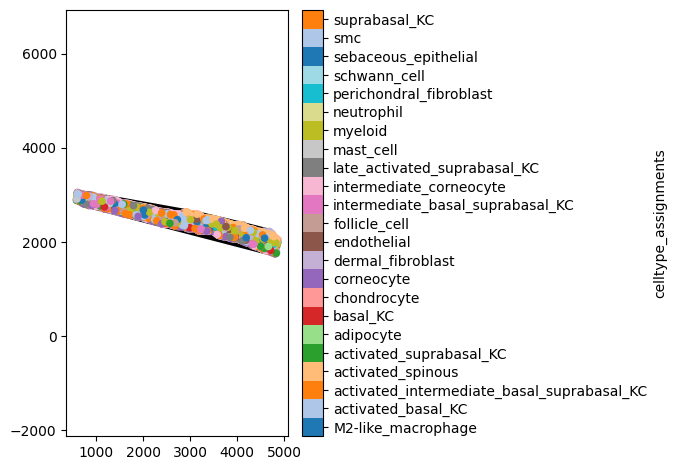

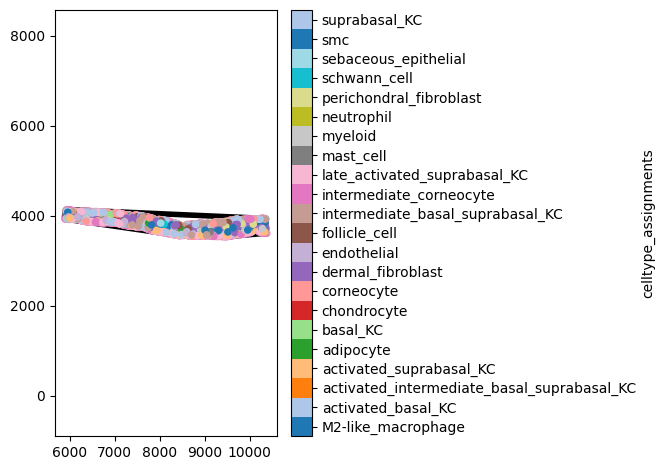

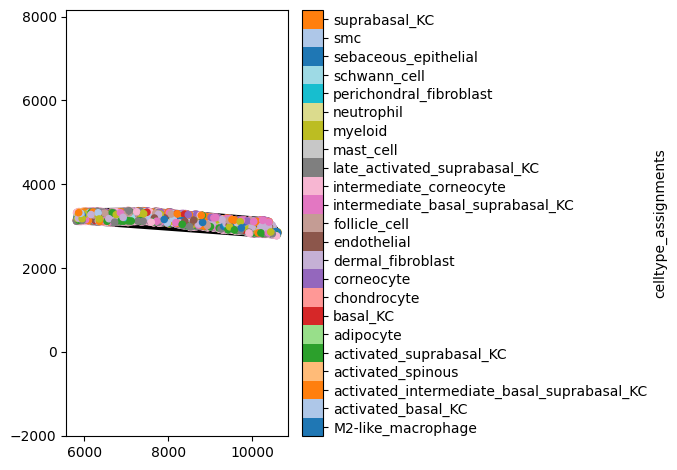

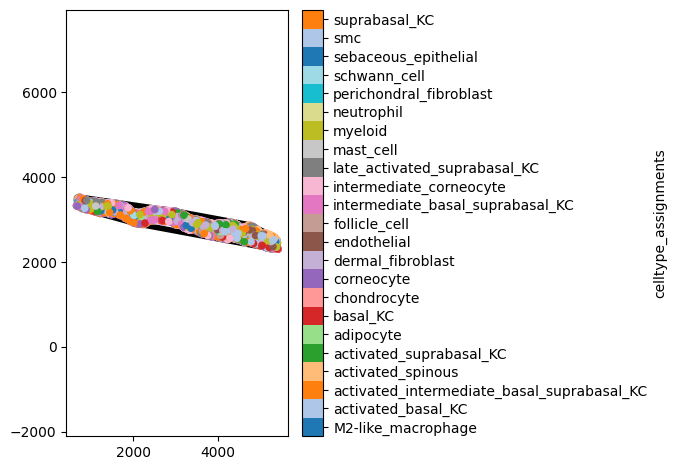

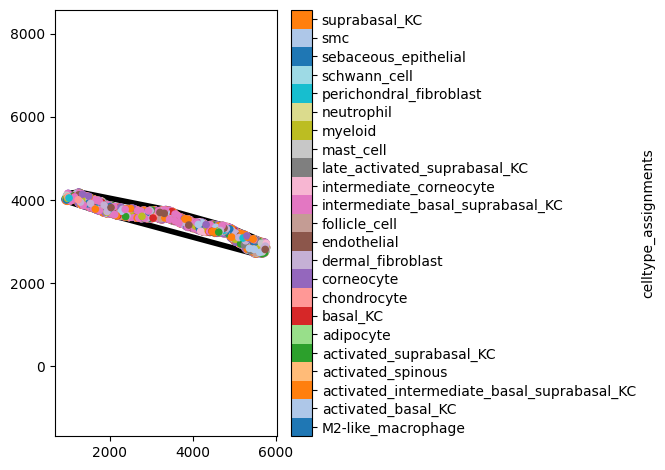

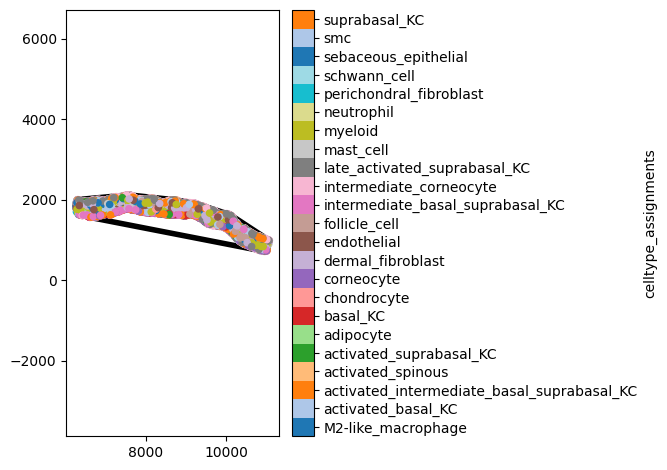

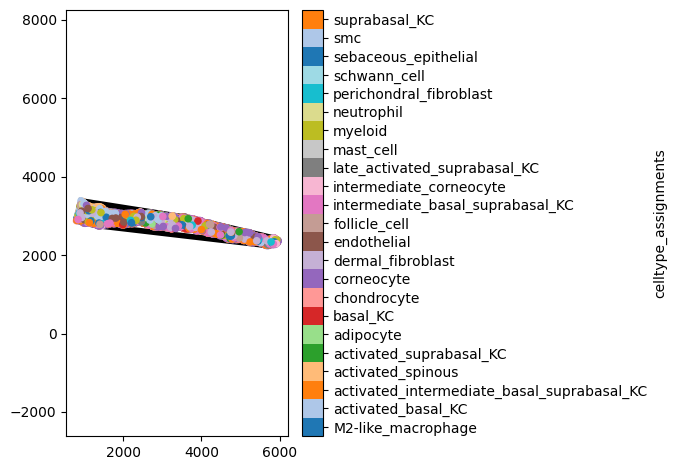

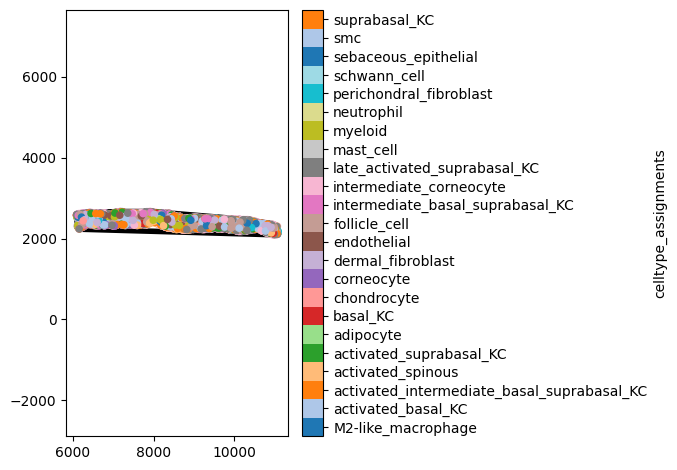

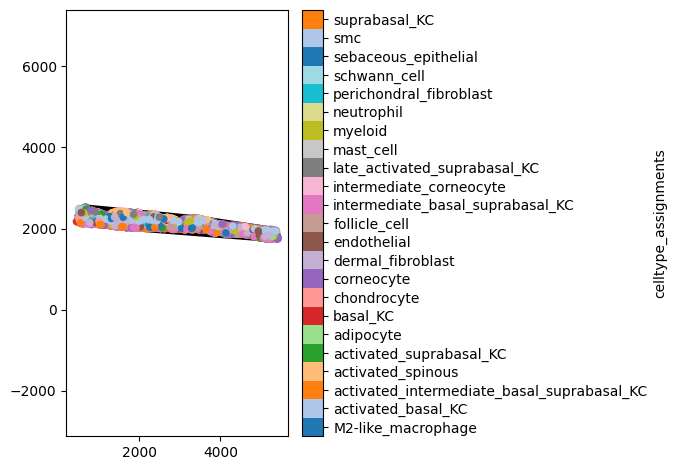

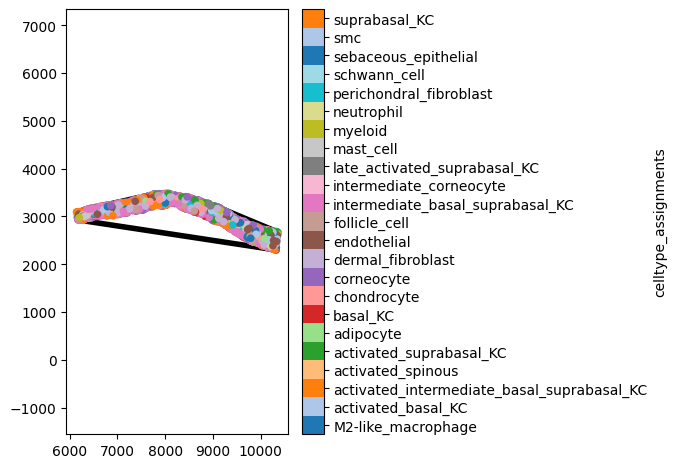

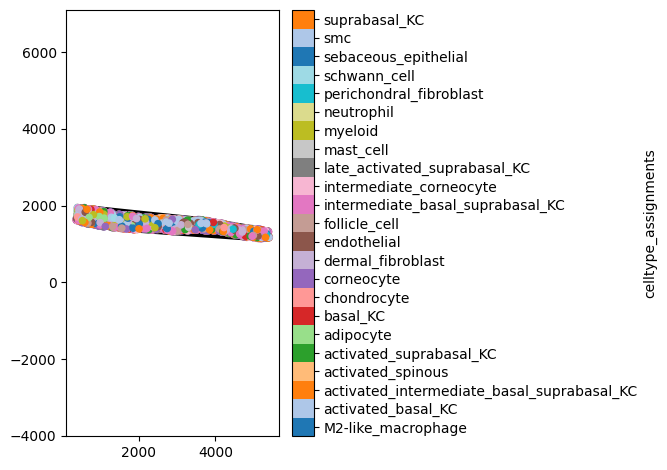

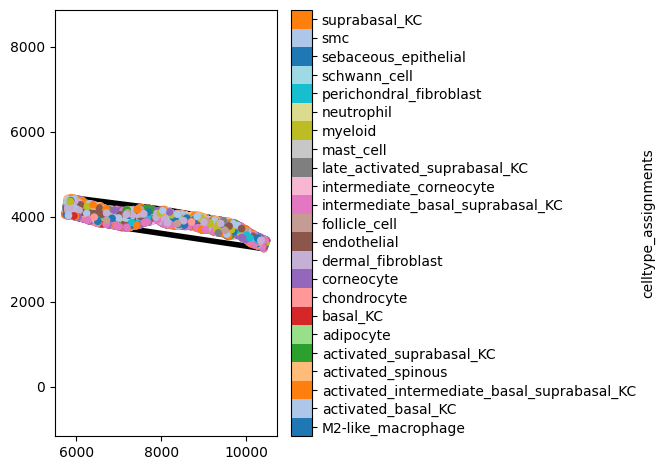

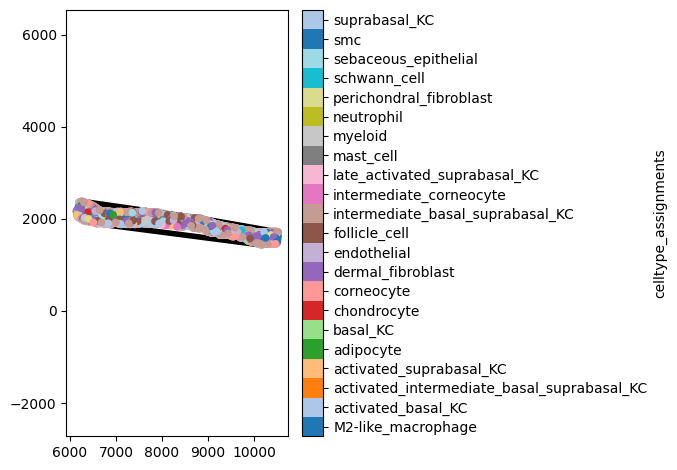

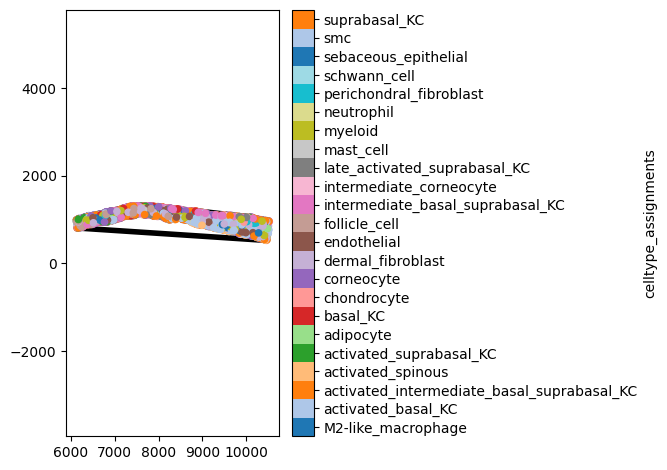

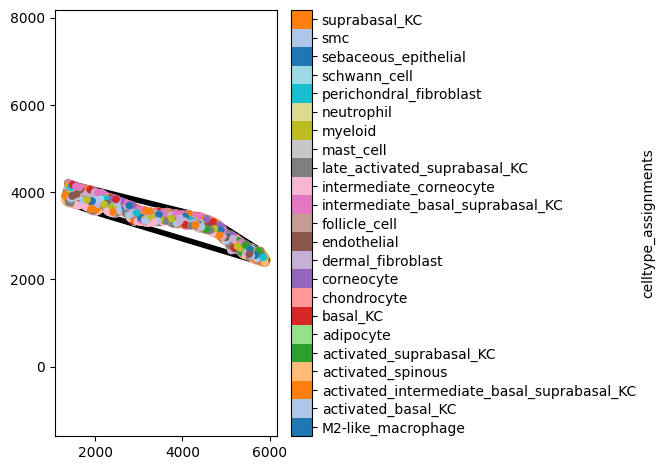

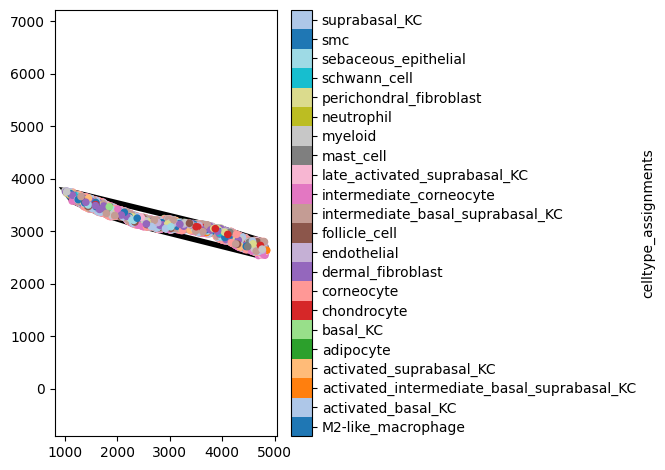

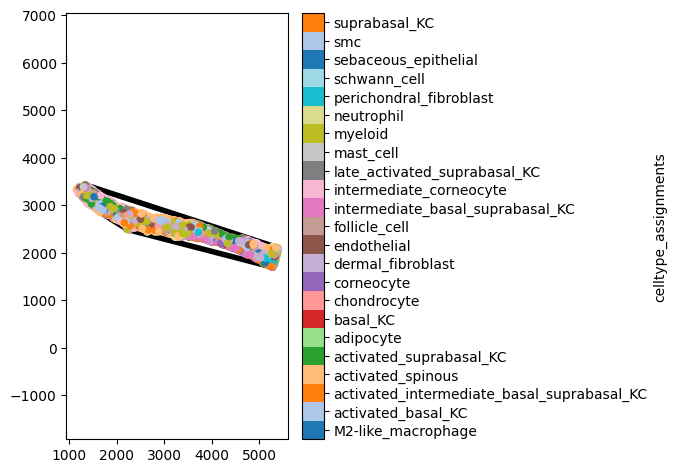

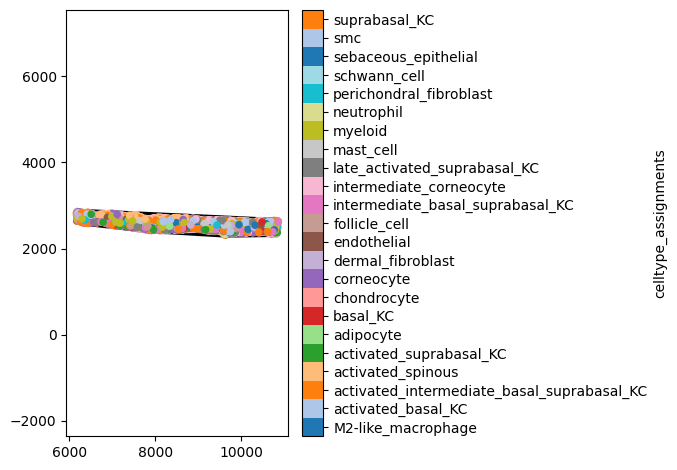

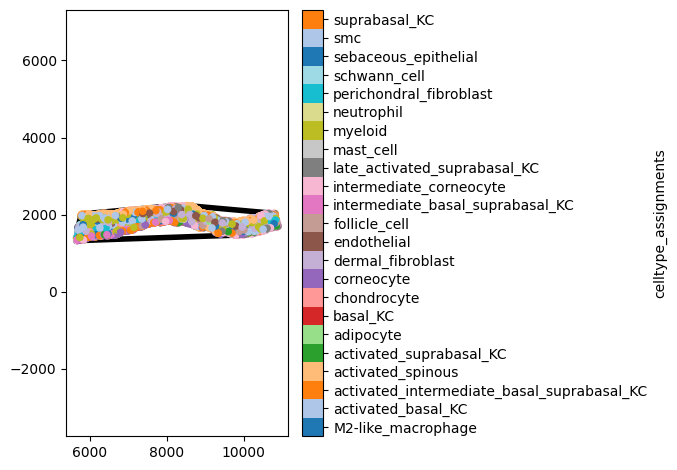

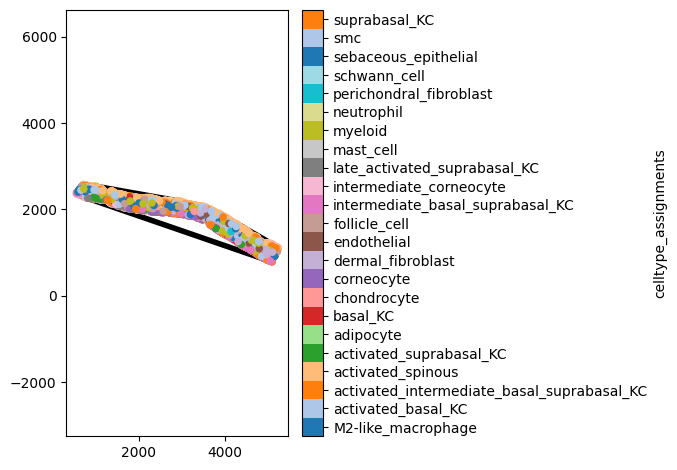

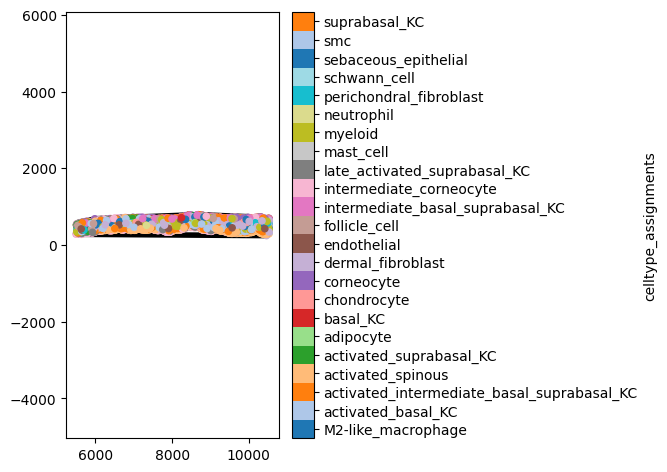

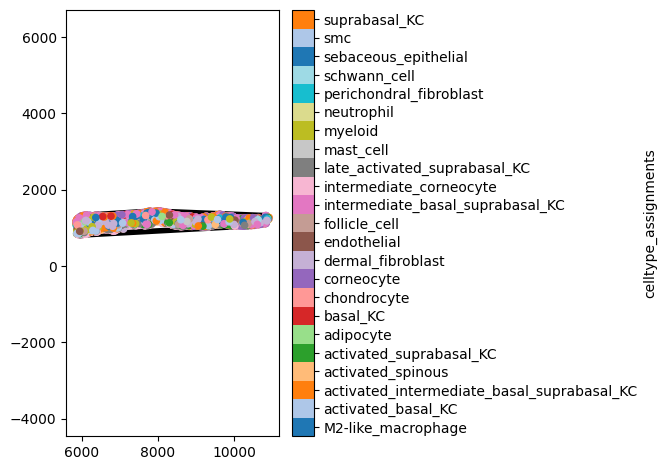

In [40]:
#visualise domains to double check
plt.figure(figsize = (8,5))

for domain in rep_domains.values():
    ms.visualise.visualise(domain, 'celltype_assignments', ax = plt.gca(), show_boundary=True)
    plt.show() 

In [5]:
#calculating network between points
for domain in rep_domains.values():
    ms.networks.generate_network(
        domain,
        network_name='proximity_150',
        network_type='Proximity',
        objects_as_nodes=('collection', 'cells'),
        max_edge_distance=200,
        min_edge_distance=0
    )
    


# #doing the neighbourhood enrichment test
enrichment_outputs = {}

for name, domain in rep_domains.items():

    SES,SES_p_val_filtered,label_categories = ms.networks.adjacency_permutation_test(domain,
                                                                                    network_name='proximity_150',
                                                                                    label_name='celltype_assignments',
                                                                                    alpha=0.05,
                                                                                    label_shuffle_iterations=1000)
    enrichment_outputs[name] = {'SES': SES,
                                'SES_p_val_filtered': SES_p_val_filtered, # |Pz|> 1.96
                                'label_categories': label_categories}


 'neutrophil'] as these have fewer than 15 observations.
 'neutrophil'] as these have fewer than 15 observations.
 'activated_suprabasal_KC' 'late_activated_suprabasal_KC' 'neutrophil'] as these have fewer than 15 observations.
 'late_activated_suprabasal_KC'] as these have fewer than 15 observations.
 'late_activated_suprabasal_KC'] as these have fewer than 15 observations.


4


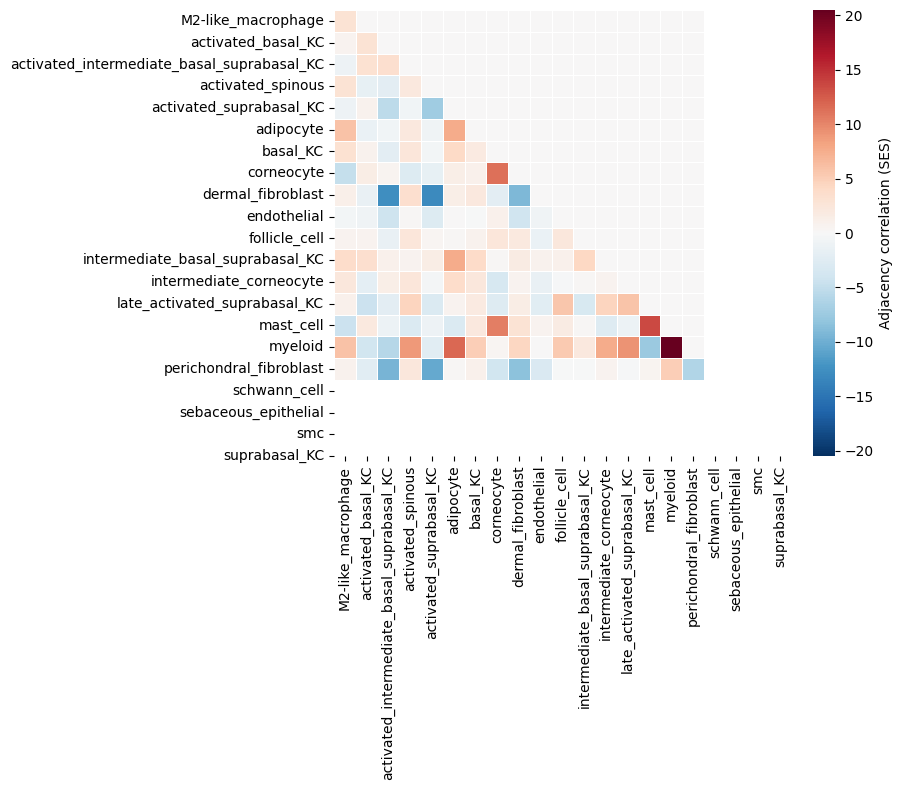

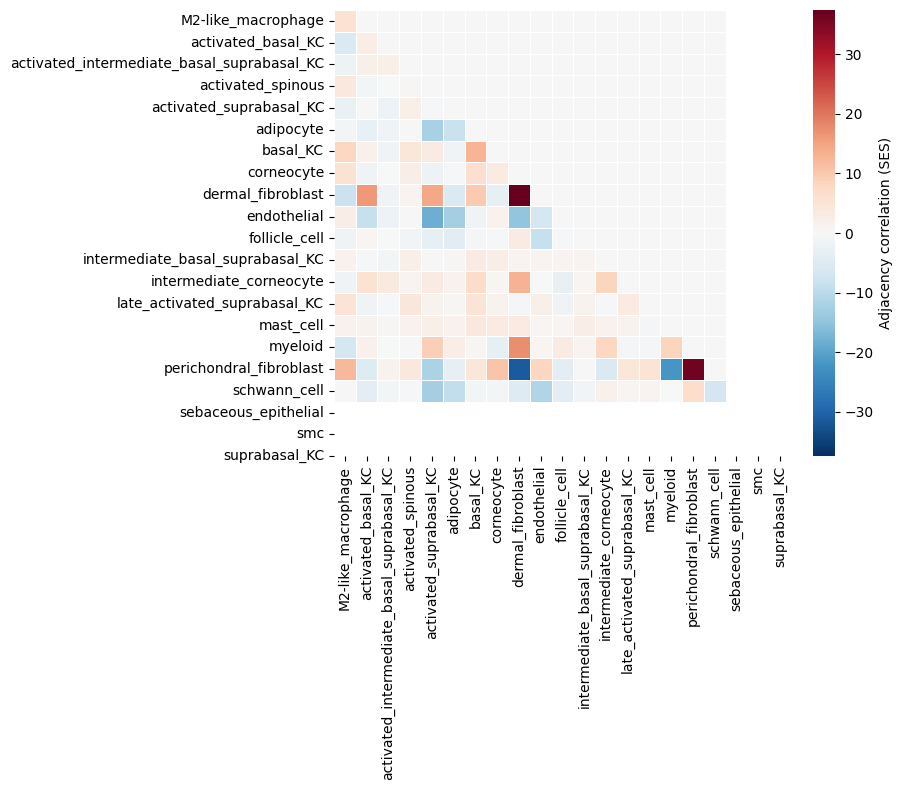

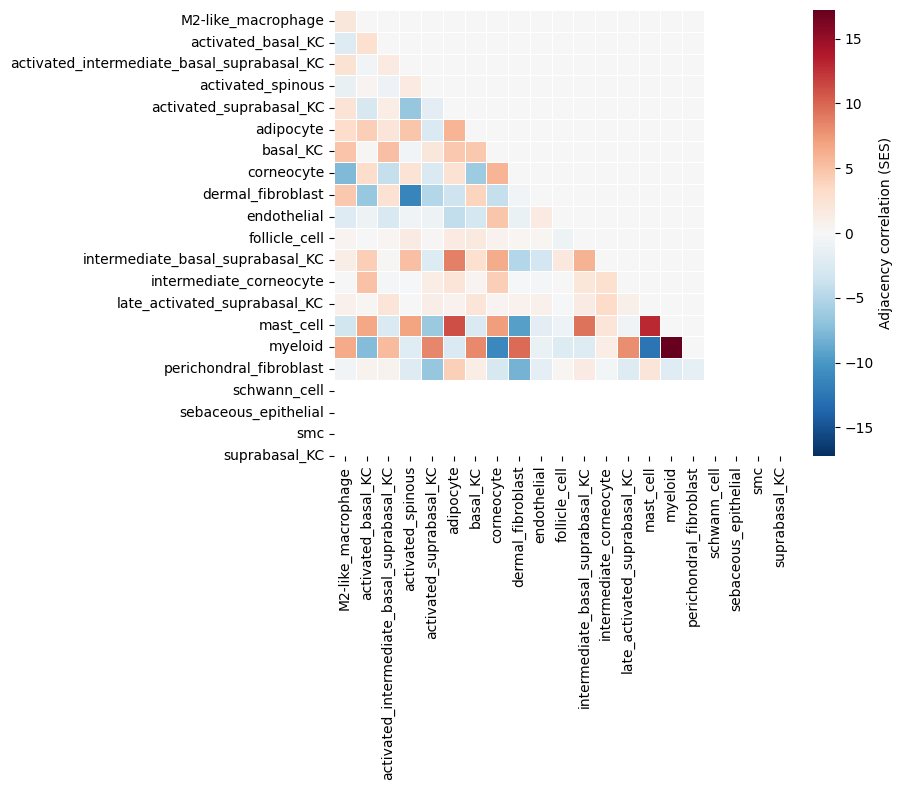

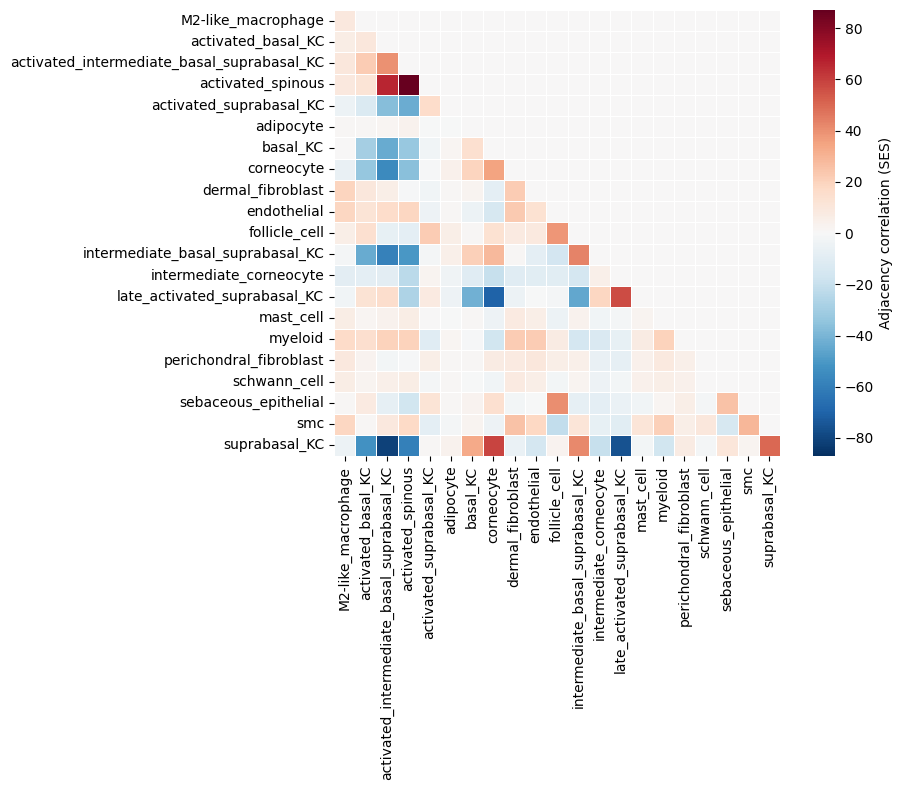

In [43]:
print(len(enrichment_outputs))
for name, dict in enrichment_outputs.items():
    len(dict)
    SES = dict['SES']
    ms.visualise.visualise_correlation_matrix(np.tril(SES),label_categories,colorbar_label='Adjacency correlation (SES)')


In [20]:
#now you want a dictionary that for each celltype-pair contains the z-scores, index by condition
#pairwise_Zscores = {'cell1|cell2':{'Ctrl':[z1, z2, z3]}}
pairwise_Zscores = {}

def add_cellpair_z(d, condition):
     categories = d['label_categories']
     for i, cell1 in enumerate(categories):
          for j, cell2 in enumerate(categories):
               if j< i: #skip lower triangle
                    continue
               key = '|'.join(sorted([cell1, cell2]))
               value = d['SES'][i,j].item()
               pairwise_Zscores.setdefault(key, {}).setdefault(condition, []).append(value)

#enrichment_outputs contains name (which is condition_replicateNumber), the SES (standard effect size (correlation) matrix), and labels ordered to align with the matrix. 
for name, d in enrichment_outputs.items():
    if 'Ctrl' in name:
        condition = 'Ctrl'
    elif 'D3IMQ' in name:
        condition = 'D3IMQ'
    elif 'D7IMQ' in name:
        condition = 'D7IMQ'
    elif 'D10IMQ' in name:
        condition = 'D10IMQ'
    else:
        continue

    if 'F' in name:
        sex = 'F'
    elif 'M' in name:
        sex = 'M'
    else:
        continue

    key = f'{condition}_{sex}'  # e.g. 'Ctrl_F', 'D3IMQ_M'
    add_cellpair_z(d, key)

In [19]:
del pairwise_Zscores

In [21]:
import pickle

save_path = "./neighbourhood_results/pairwise_zscores_sexsplit.pkl"

with open(save_path, 'wb') as f:
    pickle.dump(pairwise_Zscores, f)

# #to open
# with open(save_path, 'rb') as f:
#     pairwise_Zscores = pickle.load(f)

In [1]:
import pickle
save_path = "./neighbourhood_results/pairwise_zscores_sexsplit.pkl"

#to open
with open(save_path, 'rb') as f:
    pairwise_Zscores = pickle.load(f)

In [2]:
pairwise_Zscores

{'M2-like_macrophage|M2-like_macrophage': {'Ctrl_F': [2.985092797066754,
   5.558478854789465,
   1.9151209405846747],
  'D10IMQ_F': [9.270761153990275,
   7.102703550174637,
   8.689343959165688,
   14.063063860218893],
  'Ctrl_M': [1.4379934174305733, 1.0590931847790324, 2.4653186798793993],
  'D10IMQ_M': [11.397371032604154,
   13.559865072927241,
   22.873342007778085,
   16.674261385954786],
  'D3IMQ_F': [5.853636248130588,
   9.547577586513157,
   6.637298336327696,
   6.117408585771928],
  'D3IMQ_M': [2.512305330793986,
   11.706242877184337,
   11.672440312352645,
   10.859536847400797],
  'D7IMQ_F': [19.97374679522708,
   1.2663944621144312,
   12.332508455423286,
   17.565494282769418],
  'D7IMQ_M': [13.202785002939935,
   21.61648730321072,
   16.47690260588793,
   17.496043306452965]},
 'M2-like_macrophage|activated_basal_KC': {'Ctrl_F': [0.8736948786540913,
   -5.3353181395907425,
   -2.171941937439304],
  'D10IMQ_F': [6.868489370317564,
   -0.2099242813872157,
   9.043949

# plotting celltype pair interactions, doing stats (ANOVA --> mann-whitney)

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
from statannotations.Annotator import Annotator
from statsmodels.stats.multitest import multipletests

def plot_celltype_interactions(pair_key, pairwise_Zscores, save_path, conditions=['Ctrl_F', 'Ctrl_M', 'D3IMQ_F', 'D3IMQ_M', 'D7IMQ_F', 'D7IMQ_M', 'D10IMQ_F', 'D10IMQ_M']):
    if pair_key not in pairwise_Zscores:
        print(f"'{pair_key}' not found. Note: keys are sorted alphabetically, try '{('|').join(sorted(pair_key.split('|')))}'")
        return

    data = pairwise_Zscores[pair_key]

    rows = []
    for condition in conditions:
        if condition in data:
            for z in data[condition]:
                rows.append({'condition': condition, 'z_score': z})

    df = pd.DataFrame(rows)

    # --- ANOVA ---
    groups = [df[df['condition'] == c]['z_score'].values for c in conditions if c in data]
    f_stat, p_value = stats.f_oneway(*groups)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(7, 5))

    sns.boxplot(data=df, x='condition', y='z_score', order=conditions,
                palette='muted', ax=ax)
    sns.stripplot(data=df, x='condition', y='z_score', order=conditions,
                  color='black', size=5, alpha=0.6, ax=ax)

    # --- Significance annotations (only if ANOVA significant) ---
    if p_value < 0.05:
        all_pairs = [(c1, c2) for i, c1 in enumerate(conditions) for c2 in conditions[i+1:]]

        pair_pvals = []
        for c1, c2 in all_pairs:
            g1 = df[df['condition'] == c1]['z_score'].values
            g2 = df[df['condition'] == c2]['z_score'].values
            _, p = stats.ttest_ind(g1, g2)
            pair_pvals.append(p)

        rejected, corrected_pvals, _, _ = multipletests(pair_pvals, method='fdr_bh')
        significant_pairs = [pair for pair, sig in zip(all_pairs, rejected) if sig]

        if significant_pairs:
            annotator = Annotator(ax, significant_pairs, data=df, x='condition', y='z_score', order=conditions)
            annotator.configure(test='Mann-Whitney', text_format='star', loc='outside', comparisons_correction='BH')
            annotator.apply_and_annotate()

    ax.set_title(f'{pair_key}\nANOVA p={p_value:.3f}', fontsize=12, y=1.7)
    ax.set_xlabel('Condition')
    ax.set_ylabel('Z-score')
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Ctrl_M vs. D3IMQ_F: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
D3IMQ_F vs. D7IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.857e-02 (ns) U_stat=0.000e+00
Ctrl_M vs. D7IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
Ctrl_F vs. D7IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
Ctrl_M vs. D10IMQ_F: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
D3IMQ_F vs. D10IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.857e-02 (ns) U_stat=0.000e+00
Ctrl_M vs. D10IMQ_M: Mann-Whitney-Wilc

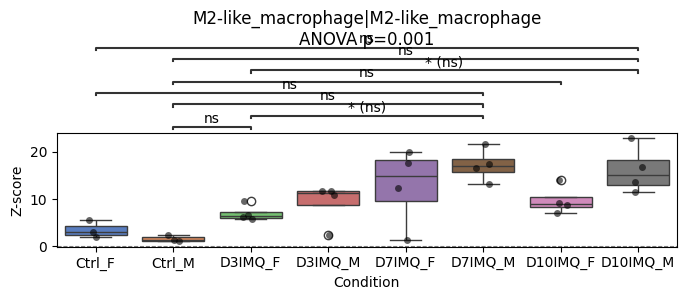

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


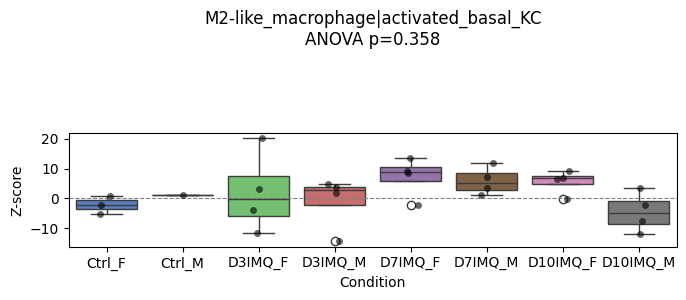

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


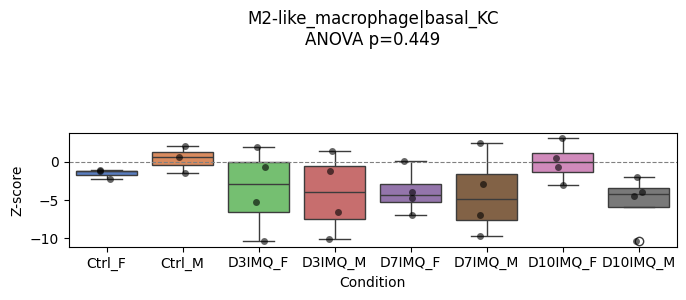

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


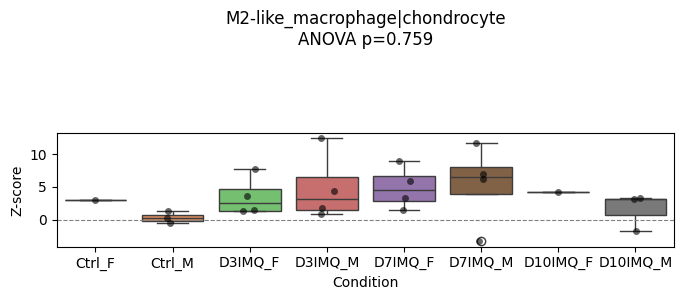

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


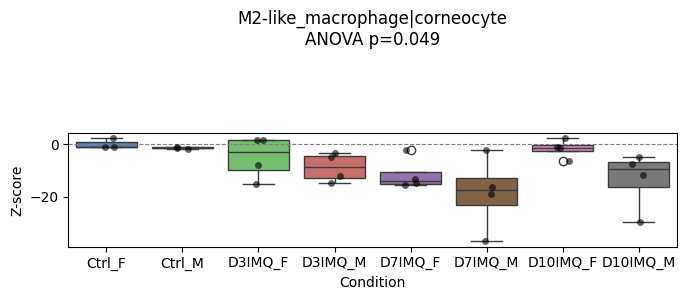

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Ctrl_M vs. D7IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
Ctrl_F vs. D7IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
Ctrl_M vs. D10IMQ_F: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
Ctrl_F vs. D10IMQ_F: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
Ctrl_M vs. D10IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
Ctrl_F vs. D10IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00


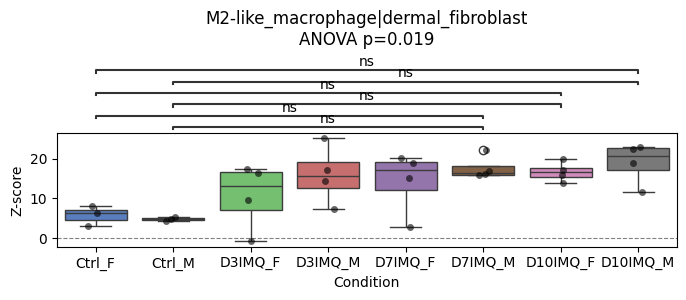

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


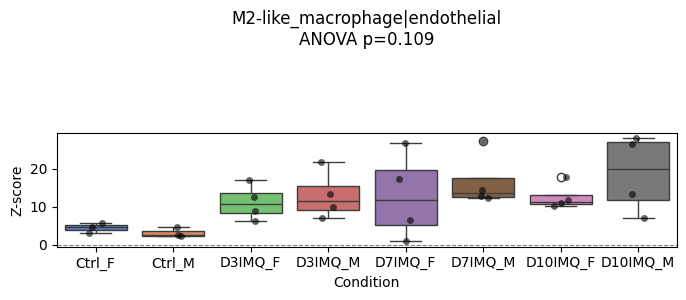

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


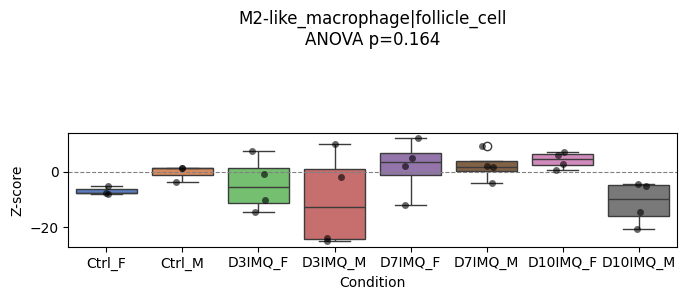

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


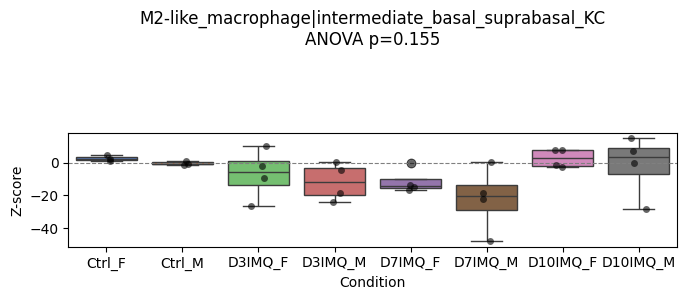

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


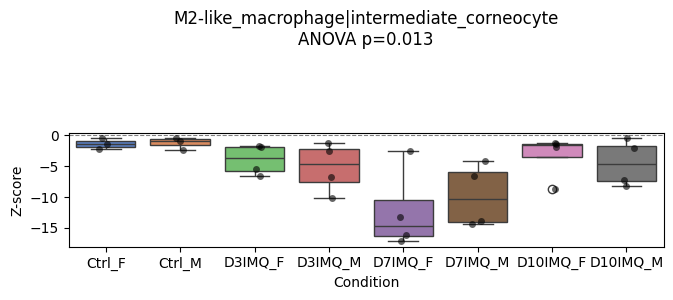

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_31460\3593561476.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='z_score', order=conditions,


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

D3IMQ_F vs. D7IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.857e-02 (ns) U_stat=0.000e+00
Ctrl_M vs. D7IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
D3IMQ_F vs. D10IMQ_F: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.857e-02 (ns) U_stat=0.000e+00
Ctrl_F vs. D7IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
D3IMQ_F vs. D10IMQ_M: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.857e-02 (ns) U_stat=0.000e+00
Ctrl_F vs. D10IMQ_F: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.714e-02 U_stat=0.000e+00
Ctrl_M vs. D10IMQ_M: Mann-Whitn

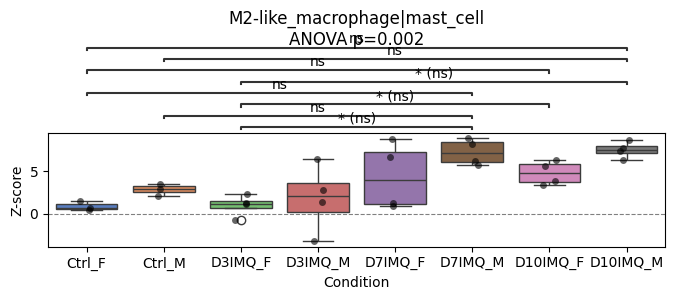

In [7]:
from pathlib import Path
results_path = Path('fda')

count = 0
for key in pairwise_Zscores.keys():
    if count >10:
        break
    count = count + 1
    plot_celltype_interactions(key, pairwise_Zscores, save_path = results_path / (key + '.png'), conditions=['Ctrl_F', 'Ctrl_M', 'D3IMQ_F', 'D3IMQ_M', 'D7IMQ_F', 'D7IMQ_M', 'D10IMQ_F', 'D10IMQ_M'])
    
    